In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
orders = pd.read_csv("supply_chain_analytics/data/orders.csv")
products = pd.read_csv("supply_chain_analytics/data/products.csv")
suppliers = pd.read_csv("supply_chain_analytics/data/suppliers.csv")
inventory = pd.read_csv("supply_chain_analytics/data/inventory.csv")

print("Data loaded successfully!")


Data loaded successfully!


In [3]:
# Checking structural info for the largest table
print(orders.info())

# Display the first 3 rows of orders
print(orders.head(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                10000 non-null  object 
 1   product_id              10000 non-null  object 
 2   quantity                10000 non-null  int64  
 3   warehouse_id            10000 non-null  object 
 4   region                  10000 non-null  object 
 5   order_date              10000 non-null  object 
 6   revenue                 10000 non-null  float64
 7   total_cost              10000 non-null  float64
 8   expected_delivery_date  10000 non-null  object 
 9   actual_delivery_date    9800 non-null   object 
 10  delivery_status         10000 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB
None
    order_id product_id  quantity warehouse_id region  order_date  revenue  \
0  ORD000001    PROD044         6     WH-South  South  2

In [4]:
# Check for missing values in orders
print("Missing values per column:")
print(orders.isnull().sum())

# Check for row duplicates
print(f"\nNumber of duplicate rows in orders: {orders.duplicated().sum()}")


Missing values per column:
order_id                    0
product_id                  0
quantity                    0
warehouse_id                0
region                      0
order_date                  0
revenue                     0
total_cost                  0
expected_delivery_date      0
actual_delivery_date      200
delivery_status             0
dtype: int64

Number of duplicate rows in orders: 0


In [5]:
# Convert text dates into proper datetime format
date_cols = ['order_date', 'expected_delivery_date', 'actual_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Data types after cleaning:")
print(orders[date_cols].dtypes)


Data types after cleaning:
order_date                datetime64[ns]
expected_delivery_date    datetime64[ns]
actual_delivery_date      datetime64[ns]
dtype: object


In [6]:
# 1. Delivery Days: Days from order to arrival
orders['delivery_days'] = (orders['actual_delivery_date'] - orders['order_date']).dt.days

# 2. Delay Days: How many days past the deadline did it arrive? (0 if on time or early)
orders['delay_days'] = (orders['actual_delivery_date'] - orders['expected_delivery_date']).dt.days
orders['delay_days'] = orders['delay_days'].apply(lambda x: x if x > 0 else 0)

# 3. Profit Margin: (Revenue - Cost) / Revenue
orders['profit_margin'] = (orders['revenue'] - orders['total_cost']) / orders['revenue']

print(orders[['delivery_days', 'delay_days', 'profit_margin']].head())


   delivery_days  delay_days  profit_margin
0            5.0         0.0       0.398618
1            2.0         0.0       0.261948
2            5.0         0.0       0.267819
3            6.0         0.0       0.456231
4            3.0         0.0       0.237107


In [7]:
# Business Trend 1: What % of total orders are delayed?
delayed_pct = (orders['delivery_status'] == 'Delayed').mean() * 100
print(f"Overall Supply Chain Delay Rate: {delayed_pct:.2f}%")

# Business Trend 2: Total Revenue and Profit by Region
region_perf = orders.groupby('region')[['revenue', 'total_cost']].sum()
region_perf['profit'] = region_perf['revenue'] - region_perf['total_cost']
print("\nRegional Financial Performance:")
print(region_perf.sort_values(by='revenue', ascending=False))


Overall Supply Chain Delay Rate: 16.95%

Regional Financial Performance:
           revenue  total_cost     profit
region                                   
West    1601600.60   987115.66  614484.94
North   1600649.12   975917.03  624732.09
South   1572572.84   965558.35  607014.49
East    1514947.21   925180.25  589766.96


In [9]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nSuppliers columns:")
print(suppliers.columns.tolist())

Orders columns:
['order_id', 'product_id', 'quantity', 'warehouse_id', 'region', 'order_date', 'revenue', 'total_cost', 'expected_delivery_date', 'actual_delivery_date', 'delivery_status', 'delivery_days', 'delay_days', 'profit_margin']

Products columns:
['product_id', 'product_name', 'category', 'unit_cost', 'unit_price', 'supplier_id']

Suppliers columns:
['supplier_id', 'supplier_name', 'supplier_rating']


In [10]:
# Merge product information with order data
orders_analysis = orders.merge(
    products[['product_id', 'product_name', 'category']],
    on='product_id',
    how='left'
)

print("Data merged successfully!")
print(orders_analysis.head())

Data merged successfully!
    order_id product_id  quantity warehouse_id region order_date  revenue  \
0  ORD000001    PROD044         6     WH-South  South 2025-02-09   825.00   
1  ORD000002    PROD092         4     WH-North  North 2025-01-21   570.80   
2  ORD000003    PROD064         1      WH-West   West 2025-08-13   180.57   
3  ORD000004    PROD077         4     WH-South  South 2025-12-21   811.08   
4  ORD000005    PROD025         8     WH-North  North 2025-10-09   485.52   

   total_cost expected_delivery_date actual_delivery_date delivery_status  \
0      496.14             2025-02-14           2025-02-14         On Time   
1      421.28             2025-01-24           2025-01-23         On Time   
2      132.21             2025-08-18           2025-08-18         On Time   
3      441.04             2025-12-27           2025-12-27         On Time   
4      370.40             2025-10-12           2025-10-12         On Time   

   delivery_days  delay_days  profit_margin    p

In [11]:
# Revenue by category
print("Revenue by Category:")
print(
    orders_analysis.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

Revenue by Category:
category
Home & Kitchen     2000882.56
Electronics        1778302.25
Office Supplies     879801.50
Apparel             855676.86
Automotive          775106.60
Name: revenue, dtype: float64


In [12]:
# Top 10 products by revenue
print("\nTop 10 Products by Revenue:")
print(
    orders_analysis.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


Top 10 Products by Revenue:
product_name
Product SKU 21    178340.40
Product SKU 15    142316.40
Product SKU 7     138357.20
Product SKU 79    135940.28
Product SKU 73    127907.87
Product SKU 8     122477.53
Product SKU 38    118622.50
Product SKU 46    117427.20
Product SKU 63    116292.95
Product SKU 59    114535.12
Name: revenue, dtype: float64


In [14]:
# Add supplier information to order data
orders_supplier = orders.merge(
    products[['product_id', 'supplier_id']],
    on='product_id',
    how='left'
)

# Average delivery time by supplier
print("Average Delivery Days by Supplier:")
print(
    orders_supplier.groupby('supplier_id')['delivery_days']
    .mean()
    .sort_values(ascending=False)
)

Average Delivery Days by Supplier:
supplier_id
SUP003    6.485507
SUP007    6.171285
SUP015    4.411765
SUP011    4.314815
SUP014    4.289902
SUP018    4.192575
SUP010    4.185336
SUP019    4.146341
SUP012    4.130307
SUP001    4.063401
SUP004    4.054852
SUP020    4.047493
SUP016    4.029579
SUP002    4.029340
SUP017    3.993481
SUP013    3.980462
SUP005    3.951844
SUP009    3.943709
SUP008    3.909091
Name: delivery_days, dtype: float64


In [15]:
# Delivery status
print("\nDelivery Status:")
print(orders['delivery_status'].value_counts())


Delivery Status:
delivery_status
On Time       8105
Delayed       1695
In Transit     200
Name: count, dtype: int64


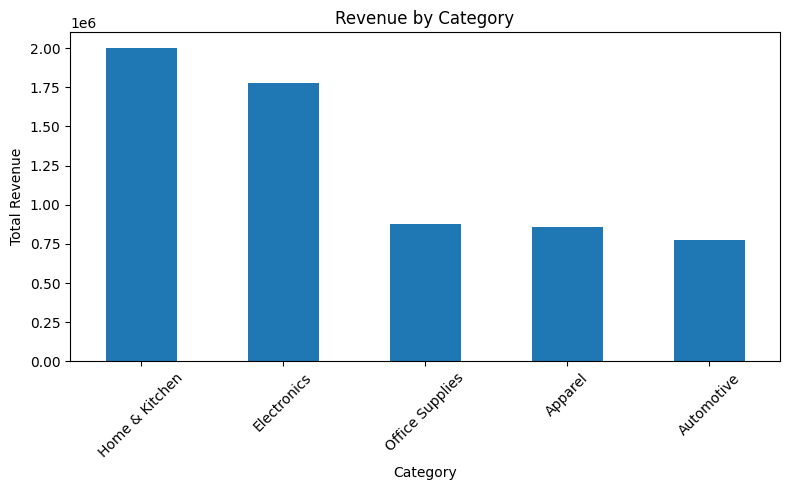

In [16]:
category_revenue = (
    orders_analysis.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

category_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

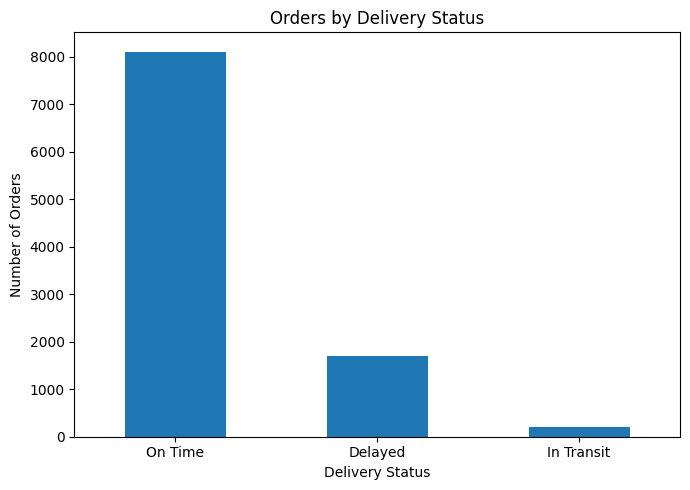

In [17]:
status_counts = orders['delivery_status'].value_counts()

status_counts.plot(kind='bar', figsize=(7,5))

plt.title('Orders by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

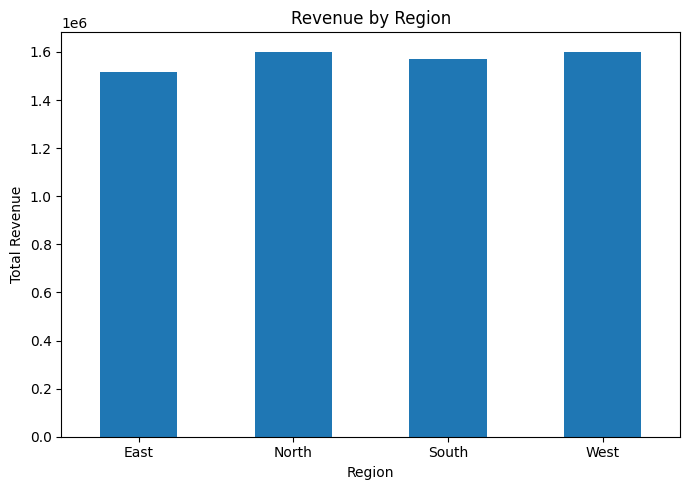

In [18]:
region_revenue = orders.groupby('region')['revenue'].sum()

region_revenue.plot(kind='bar', figsize=(7,5))

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

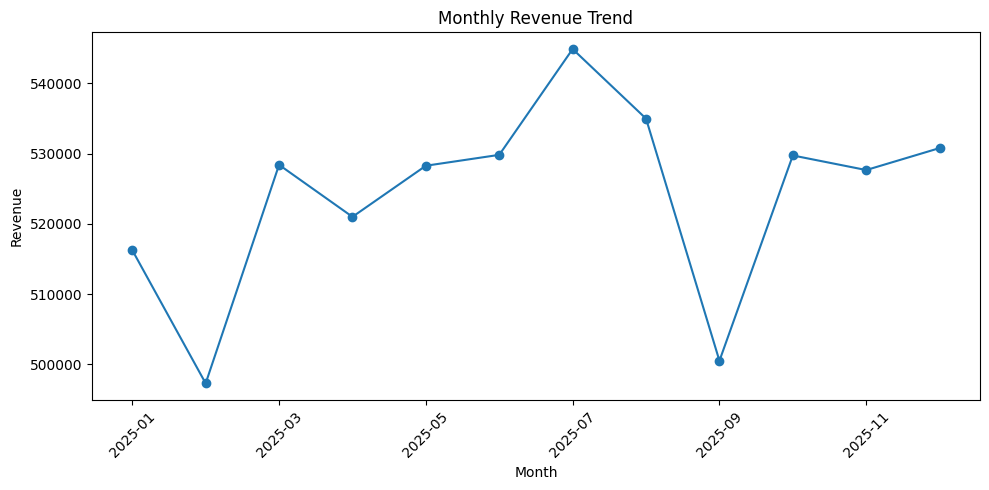

In [19]:
orders['month'] = orders['order_date'].dt.to_period('M').astype(str)

monthly_revenue = orders.groupby('month')['revenue'].sum()

monthly_revenue.plot(kind='line', marker='o', figsize=(10,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()